In [201]:
import warnings
warnings.filterwarnings('ignore')

In [202]:
import pandas as pd
import numpy as np
import pyreadr
import joblib

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm

from dash import Dash, html, dcc, dash_table, Input, Output, callback
import dash_bootstrap_components as dbc

In [203]:
pd.set_option('display.max_columns', 100)

In [204]:
dem_uncont = pd.read_csv('transformed/dem_uncontested_seats.csv')
rep_uncont = pd.read_csv('transformed/rep_uncontested_seats.csv')

In [205]:
seat_sims = pyreadr.read_r('model_output/tot_seats_sims.RDS')[None]
seat_sims = seat_sims.rename({None: 'seats'}, axis=1)
seat_sims['seats'] = seat_sims['seats'].map(lambda x: x + dem_uncont.shape[0])
seat_sims['winner'] = seat_sims['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims

,seats,winner
0,215,Republicans
1,222,Democrats
2,236,Democrats
3,219,Democrats
4,200,Republicans
...,...,...
19995,224,Democrats
19996,225,Democrats
19997,224,Democrats
19998,224,Democrats


In [206]:
sim_counts = seat_sims.groupby(['seats']).count().reset_index().rename({'winner': 'count'}, axis=1)
n_sims = seat_sims.shape[0]
sim_counts['pct'] = sim_counts['count'] / n_sims * 100
sim_counts['winner'] = sim_counts['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims = pd.merge(left=seat_sims.drop(['winner'], axis=1), right=sim_counts, on='seats', how='left')
def get_desc(winner, pct, seats):
    return f'{winner} wins {seats if seats >= 218 else (435-seats)} seats in {pct:.2f}% of simulations'
#seat_sims['desc'] = seat_sims[['winner', 'pct', 'seats']].apply(lambda x: get_desc(x['winner'], x['pct'], x['seats']), axis=1)
sim_counts.head()

,seats,count,pct,winner
0,108,1,0.005,Republicans
1,141,1,0.005,Republicans
2,150,1,0.005,Republicans
3,157,1,0.005,Republicans
4,161,4,0.020,Republicans


In [207]:
np.unique(seat_sims['seats']).shape[0]

185

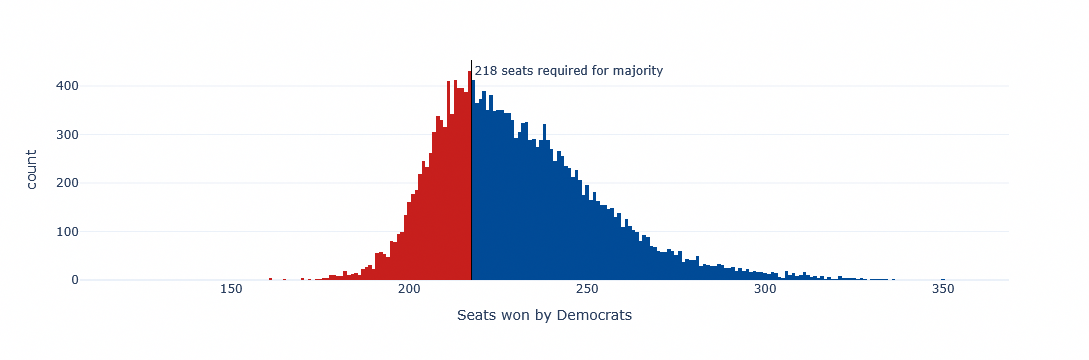

In [208]:
sims_hist = px.histogram(seat_sims, x='seats', nbins=np.unique(seat_sims['seats']).shape[0]*2, color='winner',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},
                         labels={'seats':'Seats won by Democrats', 'winner': 'Winner'}, template='plotly_white')
sims_hist.update_traces(showlegend=False)
sims_hist.add_vline(x=217.5, line_width=1, line_color='black', annotation_text='218 seats required for majority', 
                    annotation_position='top right')
sims_hist

In [209]:
output_ts = pd.read_csv('model_output/output_over_time.csv')
output_ts.head()

,date,y,geo,type
0,2026-08-30,229.365800,US House,seats
1,2026-08-30,66.120000,US House,chance
2,2026-08-30,22.784344,US House,seats_sd
3,2026-08-30,44.972806,AK-AL,y_pred
4,2026-08-30,3.555839,AK-AL,y_pred_sd


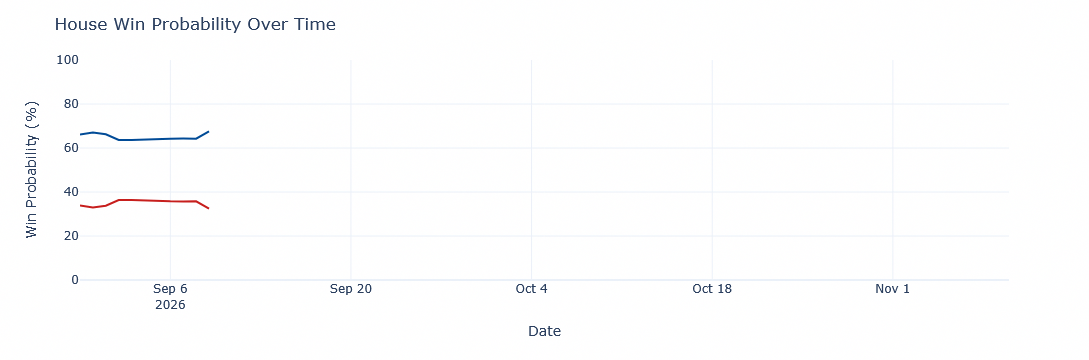

In [210]:
chance_over_time = output_ts[(output_ts['geo'] == 'US House') &
                             (output_ts['type'] == 'chance')]
chance_over_time['rep_chance'] = chance_over_time['y'].map(lambda x: 100 - x)
chance_over_time = chance_over_time.rename({'y': 'Democrats', 'rep_chance': 'Republicans'}, axis=1)
chance_time_ser = px.line(chance_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
chance_time_ser.update_traces(hovertemplate="%{y:.1f}%")
chance_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-08-30'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 100]),
    xaxis_title='Date',
    yaxis_title='Win Probability (%)',
    title=dict(text="House Win Probability Over Time"),
    hovermode="x",
    showlegend=False
)
chance_time_ser

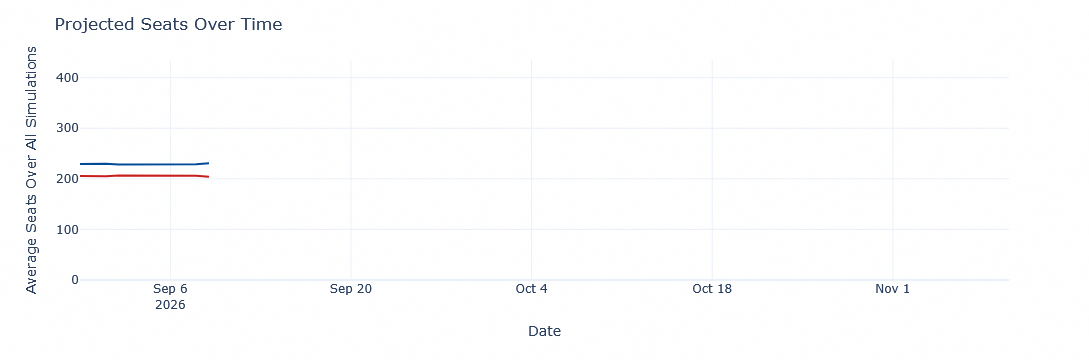

In [211]:
seats_over_time = output_ts[(output_ts['geo'] == 'US House') &
                             (output_ts['type'] == 'seats')]
seats_over_time['rep_seats'] = seats_over_time['y'].map(lambda x: 435 - x)
seats_over_time = seats_over_time.rename({'y': 'Democrats', 'rep_seats': 'Republicans'}, axis=1)
seats_time_ser = px.line(seats_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                        color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
seats_time_ser.update_traces(hovertemplate="%{y:.1f}")
seats_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-08-30'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 435]),
    xaxis_title='Date',
    yaxis_title='Average Seats Over All Simulations',
    title=dict(text="Projected Seats Over Time"),
    hovermode="x",
    showlegend=False
)
seats_time_ser

In [212]:
joblib.dump(sims_hist, 'display_data/sims_histogram.pkl')
joblib.dump(chance_time_ser, 'display_data/chance_time_ser.pkl')
joblib.dump(seats_time_ser, 'display_data/seats_time_ser.pkl')

['display_data/seats_time_ser.pkl']

In [213]:
# posterior prediction
post = pyreadr.read_r('model_output/labeled_posterior.RDS')[None]
post_untransp = post.copy()

In [214]:
post = post.T
post.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,19950,19951,19952,19953,19954,19955,19956,19957,19958,19959,19960,19961,19962,19963,19964,19965,19966,19967,19968,19969,19970,19971,19972,19973,19974,19975,19976,19977,19978,19979,19980,19981,19982,19983,19984,19985,19986,19987,19988,19989,19990,19991,19992,19993,19994,19995,19996,19997,19998,19999
AK-AL,-4.163579,-6.181264,-2.639634,-9.242625,-12.483896,2.400755,-1.080007,-6.449617,-4.707456,-5.462884,-3.695835,-6.404391,-3.961732,-5.403317,-4.307343,-6.501556,-2.101192,-3.414395,-2.593184,-3.333904,-3.366708,-6.323708,-7.291056,-3.838866,-4.402274,-2.016301,-6.407150,-2.751848,-8.467718,-4.551407,-6.441227,-6.603171,-3.865957,-8.092053,-3.262216,-10.303716,-2.772204,-13.096686,4.683511,-14.238408,4.929428,4.292217,-1.951451,-7.429548,-4.330715,-4.267080,-0.328387,-3.978661,-7.049075,-1.609154,...,-3.609679,-10.491259,-1.533653,-14.592516,2.413330,-6.975834,-5.831539,-3.889264,-0.987031,-3.486289,-4.314554,-0.958148,-8.290538,-0.427204,-7.712707,-3.508828,-3.784140,-2.814568,-3.922530,-8.959637,-2.273543,-2.378354,-11.526121,-6.600446,-1.666693,-8.521930,-6.878878,-2.511267,-6.707817,-3.485348,-8.617583,0.584222,-5.297865,1.922564,1.433844,-8.110241,0.772755,-3.829195,-3.572312,-5.797787,-9.154456,-9.749117,-13.809866,-5.727625,-3.214676,-7.683658,-5.655997,-5.788851,-8.885186,-5.363878
AL-01,-16.173303,-12.649281,-12.574073,-15.271351,-18.476841,-9.543560,-10.172822,-16.858336,-12.675948,-13.556482,-16.462342,-14.699739,-16.859215,-9.000056,-14.045738,-11.318068,-13.036830,-8.011021,-17.838218,-14.427738,-15.071486,-13.889805,-13.535378,-13.851459,-12.251213,-13.027364,-13.365578,-12.820680,-14.497601,-12.817422,-15.678481,-17.029513,-16.487356,-21.395398,-9.791694,-16.132378,-11.690927,-25.473091,-4.692811,-18.352986,-5.966549,-3.032112,-8.658439,-17.536281,-12.865802,-17.160991,-12.822823,-12.552298,-12.381002,-10.172228,...,-13.135479,-15.806095,-10.788278,-19.554336,-7.134908,-13.371924,-11.275008,-15.111846,-14.086032,-10.364282,-14.498607,-8.922881,-17.591346,-10.177288,-18.145025,-17.186630,-11.499439,-11.345988,-16.220003,-21.760696,-7.313674,-11.238627,-20.177553,-12.155069,-12.195839,-16.231522,-14.895650,-8.992796,-15.755250,-10.115121,-15.864416,-8.898448,-18.413970,-7.308278,-8.062398,-18.837830,-8.620599,-15.531015,-13.459720,-15.851636,-18.519836,-21.840672,-24.589597,-14.291212,-14.670500,-14.366078,-13.768667,-15.208947,-10.676746,-16.517987
AL-02,-5.815312,0.471502,-1.358385,0.469249,-4.010577,-4.057262,-1.949632,-5.056486,1.879886,-3.000502,0.443115,-6.421462,-0.043283,-6.791892,0.063499,-8.895244,4.836699,-2.582090,0.569641,-3.427314,2.218666,-7.577116,-3.221600,-1.930837,-3.080712,0.957891,0.203636,-2.212995,3.213183,-0.812283,1.302187,-3.211058,-7.446044,-7.590575,1.421428,-7.220091,2.007855,-6.387872,-1.728806,-7.601192,1.635376,-1.015103,2.208108,-2.155361,3.477642,-3.159797,2.587958,-1.788449,-3.362957,4.359057,...,0.207214,-1.087508,-5.186396,-4.513539,2.309848,-8.300563,-2.752072,-0.409438,-5.995965,2.269435,-2.255934,-1.485487,-2.832680,-4.931482,-0.875618,-0.878028,-1.067019,0.138239,-2.797731,-3.393946,7.630167,3.799592,-4.347458,-1.062054,-5.232012,-6.410646,-1.221821,1.398912,0.861726,1.010677,-3.078592,-0.122525,-2.167177,1.283559,2.508137,1.643018,-0.240235,-1.483314,-2.160227,1.655784,-4.067334,-8.612672,-4.865398,-2.704045,-1.616333,0.925189,-2.500762,-6.445271,1.038596,-6.393915
AL-03,-20.927391,-22.342776,-19.280022,-25.611505,-30.418803,-14.260841,-17.167519,-17.582477,-22.389064,-19.906081,-19.807377,-19.229396,-21.929152,-17.161911,-22.224236,-18.702348,-20.966242,-20.801031,-21.672300,-18.113376,-22.591502,-21.414518,-20.969465,-19.676848,-23.238919,-17.056904,-22.971187,-21.519865,-25.396780,-21.428349,-20.656817,-19.836102,-21.032642,-24.593666,-19.246060,-18.545213,-19.147617,-27.667252,-13.674026,-28.611464,-15.682456,-11.171824,-17.8290

In [215]:
sim_corr = post_untransp.corr()

In [216]:
sim_corr

,AK-AL,AL-01,AL-02,AL-03,AL-04,AL-05,AL-06,AL-07,AR-01,AR-02,AR-03,AR-04,AZ-01,AZ-02,AZ-03,AZ-04,AZ-05,AZ-06,AZ-07,AZ-08,AZ-09,CA-01,CA-02,CA-03,CA-05,CA-06,CA-08,CA-09,CA-10,CA-13,CA-15,CA-16,CA-17,CA-18,CA-19,CA-20,CA-21,CA-22,CA-23,CA-24,CA-25,CA-26,CA-27,CA-28,CA-30,CA-31,CA-32,CA-33,CA-35,CA-36,...,TX-25,TX-26,TX-27,TX-28,TX-29,TX-30,TX-31,TX-32,TX-33,TX-34,TX-35,TX-36,TX-37,TX-38,UT-01,UT-02,UT-03,UT-04,VA-01,VA-02,VA-03,VA-04,VA-05,VA-06,VA-07,VA-08,VA-09,VA-10,VA-11,VT-AL,WA-01,WA-02,WA-03,WA-04,WA-05,WA-06,WA-07,WA-08,WA-09,WA-10,WI-01,WI-03,WI-04,WI-05,WI-06,WI-07,WI-08,WV-01,WV-02,WY-AL
AK-AL,1.000000,0.727336,0.505306,0.752859,0.739800,0.728767,0.746324,0.515061,0.747755,0.750800,0.750764,0.748290,0.515516,0.511515,0.513093,0.528798,0.714804,0.730712,0.738847,0.731640,0.752328,0.715701,0.526099,0.537606,0.751842,0.744841,0.587659,0.530311,0.534060,0.530607,0.504844,0.716235,0.588440,0.527497,0.527628,0.718925,0.530102,0.751071,0.743567,0.535719,0.530021,0.719137,0.512081,0.534427,0.507945,0.548112,0.571581,0.531026,0.584868,0.534585,...,0.747384,0.731419,0.566446,0.528165,0.528566,0.714673,0.755322,0.712761,0.554238,0.529835,0.716334,0.547445,0.515713,0.509876,0.513826,0.743602,0.730189,0.732986,0.758076,0.571621,0.530295,0.508049,0.733868,0.748382,0.509246,0.534250,0.745565,0.505198,0.714529,0.547988,0.535227,0.531820,0.514696,0.715481,0.559793,0.506764,0.523509,0.525164,0.589530,0.520840,0.746686,0.567790,0.589870,0.746185,0.755340,0.714176,0.732847,0.745463,0.731508,0.714556
AL-01,0.727336,1.000000,0.511628,0.752297,0.744702,0.739695,0.754651,0.522237,0.746010,0.749856,0.751849,0.749517,0.518098,0.515322,0.517088,0.533235,0.715858,0.732078,0.740379,0.733278,0.749516,0.714342,0.525960,0.539460,0.753970,0.738113,0.593541,0.536121,0.535099,0.533427,0.512488,0.712258,0.592956,0.530560,0.529989,0.717728,0.530926,0.753840,0.739776,0.533700,0.532535,0.712410,0.515965,0.535505,0.509142,0.559215,0.580088,0.535507,0.589549,0.535920,...,0.746090,0.729235,0.575187,0.530505,0.533036,0.708398,0.755778,0.715018,0.558184,0.536183,0.714214,0.553203,0.515404,0.521183,0.518927,0.746325,0.731745,0.732941,0.753978,0.570390,0.535103,0.512238,0.727715,0.743217,0.509666,0.535855,0.748893,0.507578,0.715925,0.548881,0.536206,0.534285,0.519293,0.718583,0.564606,0.510197,0.525991,0.526297,0.597645,0.521307,0.747324,0.570650,0.593415,0.747475,0.754748,0.719294,0.733742,0.748325,0.726258,0.717876
AL-02,0.505306,0.511628,1.000000,0.519712,0.510765,0.500575,0.521619,0.714061,0.516170,0.520217,0.523033,0.521024,0.697627,0.684353,0.687969,0.712720,0.650849,0.500194,0.509809,0.499533,0.520742,0.651182,0.717577,0.723971,0.529619,0.508888,0.604507,0.715352,0.722679,0.545096,0.689519,0.649497,0.597861,0.716167,0.714067,0.653269,0.717074,0.520223,0.510941,0.722798,0.721315,0.655117,0.693953,0.715664,0.686214,0.570646,0.587117,0.720760,0.600910,0.721741,...,0.517081,0.500712,0.582850,0.716471,0.710600,0.654171,0.521854,0.658082,0.565191,0.712798,0.658374,0.555507,0.698193,0.697141,0.691399,0.517406,0.499117,0.506566,0.521321,0.573885,0.712868,0.686400,0.502727,0.511531,0.688362,0.720918,0.516794,0.686589,0.652896,0.559146,0.720214,0.718201,0.695495,0.657797,0.576646,0.687420,0.712226,0.714208,0.607436,0.701437,0.515228,0.576475,0.605226,0.515681,0.517328,0.653162,0.501716,0.513601,0.493345,0.652994
AL-03,0.752859,0.752297,0.519712,1.000000,0.770432,0.755199,0.776527,0.532295,0.773991,0.776993,0.768868,0.775069,0.525844,0.521959,0.525039,0.540486,0.733261,0.751502,0.757225,0.751072,0.775628,0.735734,0.537740,0.545693,0.775172,0.762036,0.602628,0.543800,0.547066,0.541885,0.519157,0.733866,0.599168,0.539740,0.539917,0.737486,0.538545,0.771460,0.762436,0.542652,0.542587,0.732266,0.523758,0.540459,0.520418,0.564285,0.587305,0.544077,0.600270,0.545923,...,0.771730,0.752045,0.582924,0.537685,0.538547,0.728785,0.776053,0.733994,0.570397,0.543952,0.734226,0.564523,0.527521,0.525122,0.526600,0.766565,0.751131,0.750760,0.778061,0.578252,0.542883,0.519869,0.75041

In [217]:
post.shape

(418, 20000)

In [218]:
def get_tipping_point(sim):
    """
    :param sim: Series representing one posterior draw or "simulation"
    :type sim: pd.Series
    """
    seats_won_dem = np.sum(sim > 0)
    if seats_won_dem >= 218 - dem_uncont.shape[0]: # Democrats win House in this draw
        sim = sim.sort_values(ascending=True)
        won_seats = sim[sim > 0]
        seat_margin = seats_won_dem - (218 - dem_uncont.shape[0])
    else: # Republicans win House in this draw
        sim = sim.sort_values(ascending=False)
        won_seats = sim[sim < 0]
        seat_margin = (435 - seats_won_dem) - (218 - rep_uncont.shape[0])
    return won_seats.iloc[seat_margin - 1], won_seats.index[seat_margin - 1]

In [219]:
tipping_points = np.array([]) # tipping point for *each sim*

for i in tqdm(range(post.shape[1])):
    sim = post.iloc[:, i]
    _, tp_seat = get_tipping_point(sim)
    tipping_points = np.append(tipping_points, tp_seat)

tipping_points

100%|███████████████████████████████████████████████████████████████████████████| 20000/20000 [00:29<00:00, 675.68it/s]


array(['FL-13', 'FL-25', 'MI-07', ..., 'MI-10', 'ME-02', 'FL-25'],
      shape=(20000,), dtype='<U32')

In [220]:
data = pd.read_csv('../../model_output/house_predictions.csv')
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.801913,0,1,0.000000,0.00000,0.000000,0.00000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.00000,0.000000,0.000000,-6.108692,-18.764506,-1,-37.529012,45.112006,3.615660,8.745,1,38.054824,52.190615
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.801913,0,0,0.000000,0.00000,0.000000,0.00000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.00000,0.000000,0.000000,-28.072369,-38.923019,0,-77.846039,36.189432,3.610748,0.005,2,29.144097,43.275743
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.801913,1,0,46.957206,0.90221,46.963324,0.90221,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.90221,0.949847,0.006119,-6.241502,-19.716169,1,-39.432338,48.143202,3.541078,29.640,3,41.184188,55.090754
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-6.801913,0,1,0.000000,0.00000,0.000000,0.00000,East South Central,2026,0.0,0.0,0.0,1,103,1,18.397008,0.00000,0.000000,0.000000,-38.840270,-45.710827,-1,-91.421653,29.591934,3.537502,0.000,4,22.578236,36.591776
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-6.801913,0,1,0.000000,0.00000,0.000000,0.00000,East South Central,2026,0.0,0.0,0.0,1,104,2,8.220432,0.00000,0.000000,0.000000,-59.132366,-47.132870,-1,-94.265741,19.869422,3.572312,0.000,5,12.880278,26.892194


In [221]:
data['tipping_point_prob'] = data['cd'].map(lambda x: np.mean(tipping_points == x) * 100)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.801913,0,1,0.000000,0.00000,0.000000,0.00000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.00000,0.000000,0.000000,-6.108692,-18.764506,-1,-37.529012,45.112006,3.615660,8.745,1,38.054824,52.190615,0.16
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.801913,0,0,0.000000,0.00000,0.000000,0.00000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.00000,0.000000,0.000000,-28.072369,-38.923019,0,-77.846039,36.189432,3.610748,0.005,2,29.144097,43.275743,0.00
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.801913,1,0,46.957206,0.90221,46.963324,0.90221,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.90221,0.949847,0.006119,-6.241502,-19.716169,1,-39.432338,48.143202,3.541078,29.640,3,41.184188,55.090754,1.24
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-6.801913,0,1,0.000000,0.00000,0.000000,0.00000,East South Central,2026,0.0,0.0,0.0,1,103,1,18.397008,0.00000,0.000000,0.000000,-38.840270,-45.710827,-1,-91.421653,29.591934,3.537502,0.000,4,22.578236,36.591776,0.00
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-6.801913,0,1,0.000000,0.00000,0.000000,0.00000,East South Central,2026,0.0,0.0,0.0,1,104,2,8.220432,0.00000,0.000000,0.000000,-59.132366,-47.132870,-1,-94.265741,19.869422,3.572312,0.000,5,12.880278,26.892194,0.00


In [222]:
data.sort_values('tipping_point_prob', ascending=False).head(10)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
229,229,NC-11,Jamie Ager,Jennifer Balkcom,False,False,NC,11,"AGER, JAMIE",no_match,2799701.44,0.00,2799701.44,100.000000,0.000000,North Carolina,NC-11,88.740422,3.902084,0.797632,1.120840,3.305854,24.807640,-7.843347,-4.057125,-5.003681,49.294326,45.192821,0.987401,-6.801913,0,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.0,0.00000,0.00000,37,3711,2,10000.000000,0.000000,0.000000,0.000000e+00,-3.205448,50.000000,0,100.000000,50.700313,3.676755,57.830,230,43.481208,57.999761,2.990
193,193,MI-10,Christina Hines,Mike Bouchard,False,False,MI,10,"HINES, CHRISTINA","BOUCHARD, MICHAEL",1135198.13,1290223.21,2425421.34,46.804162,53.195838,Michigan,MI-10,76.551128,2.316124,5.150984,0.123322,13.269372,29.340000,-2.765891,-2.592362,-2.635744,99.999226,46.657584,0.987401,-6.801913,0,0,45.000000,0.350776,45.000000,0.350776,East North Central,2026,0.0,0.00000,0.00000,26,2610,0,2190.629568,0.350776,0.592264,-1.460326e-07,1.530425,-3.195838,0,-6.391676,50.407335,3.675210,54.200,194,43.239937,57.705065,2.775
183,183,ME-02,Matt Dunlap,Paul LePage,False,False,ME,2,"DUNLAP, MATT","LEPAGE, PAUL",1181075.25,1418549.45,2599624.70,45.432529,54.567471,Maine,ME-02,94.623805,1.542589,0.598455,0.552005,0.848532,26.920000,-5.410176,-3.867301,-4.253020,26.830060,45.382645,0.987401,-6.801913,0,0,48.971709,0.152052,48.006269,0.152052,New England,2026,0.0,0.25284,-0.25284,23,2302,2,2064.114706,0.152052,0.389938,-9.654400e-01,-1.704127,-4.567471,0,-9.134942,49.735744,3.691724,46.830,184,42.434971,57.035216,2.660
273,273,NY-17,Cait Conley,Mike Lawler,False,True,NY,17,"CONLEY, CAIT","LAWLER, MICHAEL VINCENT",3706160.25,3186004.97,6892165.22,53.773526,46.226474,New York,NY-17,70.961924,14.978446,4.840493,0.059866,7.686273,48.490000,2.820018,1.029915,1.477441,87.206472,50.279862,0.987401,-6.801913,0,1,45.156078,0.244989,49.869935,0.244989,Mid-Atlantic,2026,0.0,0.00000,0.00000,36,3617,0,2891.592088,0.244989,0.494964,4.713858e+00,9.756795,3.773526,-1,7.547052,50.771489,3.536315,58.720,274,43.858975,57.756017,2.585
84,84,FL-07,Bale Dalton,Ryan Elijah,False,False,FL,7,"DALTON, BALE","ELIJAH, RYAN",1196852.72,221855.46,1418708.18,84.362150,15.637850,Florida,FL-07,66.558362,19.398792,2.991603,0.123627,9.057449,25.552545,-5.072419,-5.558666,-5.437104,94.888595,43.691280,0.987401,-6.801913,0,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.0,0.00000,0.00000,12,1207,0,7116.972318,0.000000,0.000000,0.000000e+00,-4.072295,34.362150,0,68.724300,49.678459,3.675571,46.165,85,42.524995,57.070499,2.565
190,190,MI-07,William Lawrence,Tom Barrett,False,True,MI,7,"LAWRENCE, WILLIAM","BARRETT, THOMAS MORE",1065694.20,3350486.21,4416180.41,24.131582,75.868418,Michigan,MI-07,85.239895,4.803904,1.944855,0.170025,5.279273,36.270000,-2.003691,0.098125,-0.427329,68.756305,49.348071,0.987401,-6.801913,0,1,48.971702,0.425524,46.971702,0.425524,East North Central,2026,0.0,0.00000,0.00000,26,2607,2,582.333253,0.425524,0.652322,-2.000000e+00,5.947255,-25.868418,-1,-51.736836,50.539241,3.575652,56.270,191,43.480865,57.539439,2.530
37,37,CA-22,Randy Villegas,David Valadao,False,True,CA,22,"VILLEGAS, RANDY","VALADAO, DAVID",2396295.54,1423592.37,3819887.91,62.732090,37.267910,California,CA-22,22.131732,64.469110,4.924433,0.538078,6.308791,6.196120,6.443675,-0.178428,1.477097,85.545753,49.071518,0.9874

In [223]:
def get_rating(dem_chance):
    if dem_chance > 100:
        raise ValueError('Invalid win chance.')
    if dem_chance > 95:
        return 'Safe D'
    elif dem_chance >= 90:
        return 'Very Likely D'
    elif dem_chance >= 75:
        return 'Likely D'
    elif dem_chance >= 65:
        return 'Lean D'
    elif dem_chance >= 60:
        return 'Tilt D'
    elif dem_chance >= 40:
        return 'Tossup'
    elif dem_chance >= 35:
        return 'Tilt R'
    elif dem_chance >= 25:
        return 'Lean R'
    elif dem_chance >= 10:
        return 'Likely R'
    elif dem_chance >= 5:
        return 'Very Likely R'
    else:
        return 'Safe R'

def get_matchup(dem_cand, rep_cand, dem_inc_any, rep_inc_any):
    indie_d = ['Bill Hill']
    indie_r = ['Kevin Kiley']
    
    if dem_cand in indie_d:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (I)'
        dem_color = '#792ba6'
    else:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (D)'
        dem_color = '#366bbf'
    
    if rep_cand in indie_r:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (I)'
        rep_color = '#792ba6'
    else:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (R)'
        rep_color = '#e63929'

    return f'<b style="color:{dem_color};">' + dem_lab + f'</b> vs <b style="color:{rep_color};">' + rep_lab + '</b>'

In [224]:
data['rating'] = data['chance'].map(lambda x: get_rating(x))
for party in ['dem', 'rep']:
    data[f'{party}_cand'] = data[f'{party}_cand'].map(lambda x: 'TBD' if x[:3] == 'TBD' else x)
data['matchup'] = data[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                          x['dem_inc_any'], x['rep_inc_any']), axis=1)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.801913,0,1,0.000000,0.00000,0.000000,0.00000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.00000,0.000000,0.000000,-6.108692,-18.764506,-1,-37.529012,45.112006,3.615660,8.745,1,38.054824,52.190615,0.16,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs..."
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.801913,0,0,0.000000,0.00000,0.000000,0.00000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.00000,0.000000,0.000000,-28.072369,-38.923019,0,-77.846039,36.189432,3.610748,0.005,2,29.144097,43.275743,0.00,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<..."
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.801913,1,0,46.957206,0.90221,46.963324,0.90221,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.90221,0.949847,0.006119,-6.241502,-19.716169,1,-39.432338,48.143202,3.541078,29.640,3,41.184188,55.090754,1.24,Lean R,"<b style=""color:#366bbf;"">Shomari Figures* (D)..."
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-6.801913,0,1,0.000000,0.00000,0.000000,0.00000,East South Central,2026,0.0,0.0,0.0,1,103,1,18.397008,0.00000,0.000000,0.000000,-38.840270,-45.710827,-1,-91.421653,29.591934,3.537502,0.000,4,22.578236,36.591776,0.00,Safe R,"<b style=""color:#366bbf;"">Lee McInnis (D)</b> ..."
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-6.801913,0,1,0.000000,0.00000,0.000000,0.00000,East South Central,2026,0.0,0.0,0.0,1,104,2,8.220432,0.00000,0.000000,0.000000,-59.132366,-47.132870,-1,-94.265741,19.869422,3.572312,0.000,5,12.880278,26.892194,0.00,Safe R,"<b style=""color:#366bbf;"">Amanda Pusczek (D)</..."


In [225]:
data['projected_winner'] = data['chance'].map(lambda x: '(D)' if x > 50 else '(R)')
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.801913,0,1,0.000000,0.00000,0.000000,0.00000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.00000,0.000000,0.000000,-6.108692,-18.764506,-1,-37.529012,45.112006,3.615660,8.745,1,38.054824,52.190615,0.16,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R)
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.801913,0,0,0.000000,0.00000,0.000000,0.00000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.00000,0.000000,0.000000,-28.072369,-38.923019,0,-77.846039,36.189432,3.610748,0.005,2,29.144097,43.275743,0.00,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R)
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.801913,1,0,46.957206,0.90221,46.963324,0.90221,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.90221,0.949847,0.006119,-6.241502,-19.716169,1,-39.432338,48.143202,3.541078,29.640,3,41.184188,55.090754,1.24,Lean R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R)


In [226]:
pvi_24 = pd.read_csv('../../transformed/pvi/past_pres_results_by24dist.csv')
data = pd.merge(left=data, right=pvi_24[['district', 'party']], left_on='cd', right_on='district')
data = data.rename({'party': 'curr_party'}, axis=1)
data['hold'] = data['projected_winner'] ==  data['curr_party']
data['flip'] = data['hold'].map(lambda x: not x)
data['flip_indic'] = data['flip'].map(lambda x: 'Flip' if x else '')
#data['flip'] = data['flip'].map(lambda x: 'Yes' if x else 'No')
data.head(2)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.801913,0,1,0.0,0.0,0.0,0.0,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.0,0.0,0.0,-6.108692,-18.764506,-1,-37.529012,45.112006,3.615660,8.745,1,38.054824,52.190615,0.16,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.801913,0,0,0.0,0.0,0.0,0.0,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.0,0.0,0.0,-28.072369,-38.923019,0,-77.846039,36.189432,3.610748,0.005,2,29.144097,43.275743,0.00,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,


In [227]:
data['projected_2p_margin'] = data['y_pred'].map(lambda y_pred: f'D+{y_pred - (100-y_pred):.1f}' if y_pred > 50 else f'R+{(100-y_pred) - y_pred:.1f}')
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.801913,0,1,0.000000,0.00000,0.000000,0.00000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.00000,0.000000,0.000000,-6.108692,-18.764506,-1,-37.529012,45.112006,3.615660,8.745,1,38.054824,52.190615,0.16,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+9.8
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.801913,0,0,0.000000,0.00000,0.000000,0.00000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.00000,0.000000,0.000000,-28.072369,-38.923019,0,-77.846039,36.189432,3.610748,0.005,2,29.144097,43.275743,0.00,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+27.6
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.801913,1,0,46.957206,0.90221,46.963324,0.90221,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.90221,0.949847,0.006119,-6.241502,-19.716169,1,-39.432338,48.143202,3.541078,29.640,3,41.184188,55.090754,1.24,Lean R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R),AL-02,(D),False,True,Flip,R+3.7


In [228]:
data['rep_chance'] = data['chance'].map(lambda x: 100 - x)
data['rounded_dem_chance'] = data['chance'].map(lambda x: np.round(x, 1))
data['rounded_rep_chance'] = data['rep_chance'].map(lambda x: np.round(x, 1))
data['disp_dem_chance'] = data['rounded_dem_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data['disp_rep_chance'] = data['rounded_rep_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.801913,0,1,0.000000,0.00000,0.000000,0.00000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.00000,0.000000,0.000000,-6.108692,-18.764506,-1,-37.529012,45.112006,3.615660,8.745,1,38.054824,52.190615,0.16,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+9.8,91.255,8.7,91.3,8.7%,91.3%
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.801913,0,0,0.000000,0.00000,0.000000,0.00000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.00000,0.000000,0.000000,-28.072369,-38.923019,0,-77.846039,36.189432,3.610748,0.005,2,29.144097,43.275743,0.00,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+27.6,99.995,0.0,100.0,<1%,>99%
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.801913,1,0,46.957206,0.90221,46.963324,0.90221,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.90221,0.949847,0.006119,-6.241502,-19.716169,1,-39.432338,48.143202,3.541078,29.640,3,41.184188,55.090754,1.24,Lean R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R),AL-02,(D),False,True,Flip,R+3.7,70.360,29.6,70.4,29.6%,70.4%


In [229]:
data['swing_24_to_26'] = data['y_pred'].astype(float).map(lambda x: x - (100 - x)) - data['dem_2p_24'].astype(float).map(lambda x: x - (100 - x))
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.801913,0,1,0.000000,0.00000,0.000000,0.00000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.00000,0.000000,0.000000,-6.108692,-18.764506,-1,-37.529012,45.112006,3.615660,8.745,1,38.054824,52.190615,0.16,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+9.8,91.255,8.7,91.3,8.7%,91.3%,3.917138
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.801913,0,0,0.000000,0.00000,0.000000,0.00000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.00000,0.000000,0.000000,-28.072369,-38.923019,0,-77.846039,36.189432,3.610748,0.005,2,29.144097,43.275743,0.00,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+27.6,99.995,0.0,100.0,<1%,>99%,8.723337
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.801913,1,0,46.957206,0.90221,46.963324,0.90221,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.90221,0.949847,0.006119,-6.241502,-19.716169,1,-39.432338,48.143202,3.541078,29.640,3,41.184188,55.090754,1.24,Lean R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R),AL-02,(D),False,True,Flip,R+3.7,70.360,29.6,70.4,29.6%,70.4%,10.750832


In [230]:
data['disp_24_to_26_swing'] = data['swing_24_to_26'].map(lambda x: f'D+{x:.1f}' if x > 0 else f'R+{abs(x):.1f}')
data.head(2)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26,disp_24_to_26_swing
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.801913,0,1,0.0,0.0,0.0,0.0,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.0,0.0,0.0,-6.108692,-18.764506,-1,-37.529012,45.112006,3.615660,8.745,1,38.054824,52.190615,0.16,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+9.8,91.255,8.7,91.3,8.7%,91.3%,3.917138,D+3.9
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.801913,0,0,0.0,0.0,0.0,0.0,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.0,0.0,0.0,-28.072369,-38.923019,0,-77.846039,36.189432,3.610748,0.005,2,29.144097,43.275743,0.00,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+27.6,99.995,0.0,100.0,<1%,>99%,8.723337,D+8.7


In [231]:
data['geoid']

0       200
1       101
2       102
3       103
4       104
       ... 
413    5507
414    5508
415    5401
416    5402
417    5600
Name: geoid, Length: 418, dtype: int64

In [232]:
dem_uclen = dem_uncont.shape[0]
dem_uncont['rating'] = np.full(dem_uclen, 'Safe D')
dem_uncont['chance'] = np.full(dem_uclen, 100)
dem_uncont['y_pred'] = np.full(dem_uclen, 100)
dem_uncont['swing_24_to_26'] = np.full(dem_uclen, float('nan')) # Placeholder
dem_uncont['disp_24_to_26_swing'] = np.full(dem_uclen, float('nan')) # Placeholder
dem_uncont['disp_dem_chance'] = np.full(dem_uclen, '100%')
dem_uncont['disp_rep_chance'] = np.full(dem_uclen, '0%')
dem_uncont['projected_2p_margin'] = np.full(dem_uclen, 'D+100')
dem_uncont['flip_indic'] = np.full(dem_uclen, '')
dem_uncont = dem_uncont.drop(['Unnamed: 0'], axis=1)
dem_uncont['matchup'] = dem_uncont[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                                      x['dem_inc_any'], x['rep_inc_any']), axis=1)
dem_uncont.head()

,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fips,geoid,rating,chance,y_pred,swing_24_to_26,disp_24_to_26_swing,disp_dem_chance,disp_rep_chance,projected_2p_margin,flip_indic,matchup
0,CA-04,Mike Thompson/Eric Jones,Not Contested,True,False,CA,4,6,604,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Mike Thompson/Eric J..."
1,CA-07,Doris Matsui/Mai Vang,Not Contested,True,False,CA,7,6,607,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Doris Matsui/Mai Van..."
2,CA-11,Scott Weiner/Connie Chan,Not Contested,False,False,CA,11,6,611,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Scott Weiner/Connie ..."
3,CA-12,Lateefah Simon,Not Contested,True,False,CA,12,6,612,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Lateefah Simon* (D)<..."
4,CA-14,Aisha Wahab/Melissa Hernandez,Not Contested,True,False,CA,14,6,614,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Aisha Wahab/Melissa ..."


In [233]:
rep_uclen = rep_uncont.shape[0]
rep_uncont['rating'] = np.full(rep_uclen, 'Safe R')
rep_uncont['chance'] = np.full(rep_uclen, 0)
rep_uncont['y_pred'] = np.full(rep_uclen, 0)
rep_uncont['swing_24_to_26'] = np.full(rep_uclen, float('nan')) # Placeholder
rep_uncont['disp_24_to_26_swing'] = np.full(rep_uclen, float('nan')) # Placeholder
rep_uncont['disp_dem_chance'] = np.full(rep_uclen, '0%')
rep_uncont['disp_rep_chance'] = np.full(rep_uclen, '100%')
rep_uncont['projected_2p_margin'] = np.full(rep_uclen, 'R+100')
rep_uncont['flip_indic'] = np.full(rep_uclen, '')
rep_uncont = rep_uncont.drop(['Unnamed: 0'], axis=1)
rep_uncont['matchup'] = rep_uncont[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                                       x['dem_inc_any'], x['rep_inc_any']), axis=1)
rep_uncont.head()

,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fips,geoid,rating,chance,y_pred,swing_24_to_26,disp_24_to_26_swing,disp_dem_chance,disp_rep_chance,projected_2p_margin,flip_indic,matchup
0,CA-40,Not Contested,Young Kim/Ken Calvert,False,True,CA,40,6,640,Safe R,0,0,NaN,NaN,0%,100%,R+100,,"<b style=""color:#366bbf;"">Not Contested (D)</b..."


In [234]:
incl_cols = ['cd', 'dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any', 'rating', 'chance', 'disp_dem_chance',
            'disp_rep_chance', 'projected_2p_margin', 'y_pred', 'flip_indic', 'geoid', 'matchup', 'swing_24_to_26', 'disp_24_to_26_swing']
disp_data = pd.concat([data[incl_cols], dem_uncont[incl_cols], rep_uncont[incl_cols]], axis=0)
disp_data.shape

(435, 16)

In [235]:
tab_data = data[['cd', 'dem_cand', 'rep_cand', 'rating', 'disp_dem_chance', 'disp_rep_chance', 'projected_2p_margin', 'disp_24_to_26_swing',
                 'tipping_point_prob']]
for party in ['dem', 'rep']:
    tab_data[f'disp_{party}_chance'] = tab_data[f'disp_{party}_chance'].map(lambda x: f'<p style="color:{'blue' if party == 'dem' else 'red'};">{x}</p>')
    tab_data[f'{party}_cand'] = tab_data[f'{party}_cand'].map(lambda x: f'{x} (Ind)' if x in ['Bill Hill', 'Kevin Kiley'] else x)
tab_data = tab_data.rename({
    'cd': 'District',
    'dem_cand': 'Democrat',
    'rep_cand': 'Republican',
    'rating': 'Rating',
    'disp_dem_chance': 'Dem Chance',
    'disp_rep_chance': 'Rep Chance',
    'projected_2p_margin': 'Projected Margin',
    'tipping_point_prob': 'Tipping Point Chance',
    'disp_24_to_26_swing': 'Swing from 2024 Pres'
}, axis=1)
tab_data.head()

,District,Democrat,Republican,Rating,Dem Chance,Rep Chance,Projected Margin,Swing from 2024 Pres,Tipping Point Chance
0,AK-AL,Bill Hill (Ind),Nick Begich,Very Likely R,"<p style=""color:blue;"">8.7%</p>","<p style=""color:red;"">91.3%</p>",R+9.8,D+3.9,0.16
1,AL-01,Clyde Jones Jr.,Jerry Carl,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+27.6,D+8.7,0.00
2,AL-02,Shomari Figures,Rhett Marques,Lean R,"<p style=""color:blue;"">29.6%</p>","<p style=""color:red;"">70.4%</p>",R+3.7,D+10.8,1.24
3,AL-03,Lee McInnis,Mike Rogers,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+40.8,D+6.2,0.00
4,AL-04,Amanda Pusczek,Robert Aderholt,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+60.3,D+6.7,0.00


In [236]:
data['rep_pred'] = data['y_pred'].map(lambda x: 100 - x)
data['projected_2p_margin_number'] = data['rep_pred'] - data['y_pred']
data['proj_seat_lean'] = data['projected_2p_margin_number'] - data['generic_ballot_avg']
sv_bias = float(data.sort_values('tipping_point_prob', ascending=False).reset_index().loc[0, 'proj_seat_lean']) # Seats-votes bias, + = R, - = D
sv_bias

5.401286936552458

In [237]:
topline_stats = pd.read_csv('display_data/topline_stats.csv')
if 'sv_bias' in topline_stats['vars'].values:
    topline_stats = topline_stats[topline_stats['vars'] != 'sv_bias']
topline_stats = pd.concat([topline_stats, pd.DataFrame({'vars': ['sv_bias'], 'x': sv_bias})], axis=0)
topline_stats.to_csv('display_data/topline_stats.csv')
topline_stats

,vars,x
0,means_seats_tot,230.831350
1,chamber_win_chance,67.540000
0,sv_bias,5.401287


In [238]:
mean_seats_tot = topline_stats[topline_stats['vars'] == 'means_seats_tot']['x'].values[0]
chamber_win_chance = topline_stats[topline_stats['vars'] == 'chamber_win_chance']['x'].values[0]

In [239]:
chances = topline_stats[topline_stats['vars'] == 'chamber_win_chance'].set_index(['vars']).T
chances['Republicans'] = chances['chamber_win_chance'].map(lambda x: 100 - x)
chances = chances.rename({'chamber_win_chance': 'Democrats'}, axis=1).T.reset_index()
chances = chances.rename({'x': 'Win Probability'}, axis=1)
seats = topline_stats[topline_stats['vars'] == 'means_seats_tot'].set_index(['vars']).T
seats['Republicans'] = seats['means_seats_tot'].map(lambda x: 435 - x)
seats = seats.rename({'means_seats_tot': 'Democrats'}, axis=1).T.reset_index().rename({'x': 'Seat Share'}, axis=1)
summary_stats = pd.merge(left=chances, right=seats, on='vars', how='inner').rename({'vars': 'Party'}, axis=1)
summary_stats.to_csv('display_data/summary_stats.csv')
summary_stats

,Party,Win Probability,Seat Share
0,Democrats,67.54,230.83135
1,Republicans,32.46,204.16865


In [240]:
disp_data.to_csv('display_data/choropleth_display_data.csv')
tab_data.to_csv('display_data/table_display_data.csv')
data.to_csv('display_data/all_data.csv')